<h1>Mental Health Dataset Analysis</h1>
- Explore, clean and analyse the dataset

Mental health dataset obtained from Kaggle. Dataset appears to contain a variety of features related to text analysis, sentiment analysis, and psychological indicators.

Dataset covers a wide range of linguistic, psychological, and behavioural attributes making it suitable for analyzing mental health-related topics in online communities.

This project explores mental health trends using survey data to identify patterns associated with stress, workplace interference, and demographic characteristics.

In [ ]:
# %pip install --upgrade plotly

In [ ]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

<h1>Notebook Presentation</h1>

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

<h1>Load Data</h1>

In [ ]:
df = pd.read_csv('Mental Health Dataset.csv')

<h1>Preliminary Data Exploration</h1>

This section explores the structure, completeness, and general characteristics of the dataset before cleaning and analysis.

In [ ]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'Columns: {df.columns.to_list()}')
df.head()

Number of rows: 292364
Number of columns: 17
Columns: ['Timestamp', 'Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


In [ ]:
# Percentage of missing data from the self-employed column
missing_NaN = df["self_employed"].value_counts(dropna=False)
counts = df['self_employed'].value_counts(normalize=True, dropna=False)
print(missing_NaN)
print(counts)
missing_data_pct = counts.iloc[2] * 100
print(f'Percentage of missing data: {missing_data_pct:.2f}%')

self_employed
No     257994
Yes     29168
NaN      5202
Name: count, dtype: int64
self_employed
No    0.88
Yes   0.10
NaN   0.02
Name: proportion, dtype: float64
Percentage of missing data: 1.78%


In [ ]:
print(df['Gender'].value_counts())
print('\n')
print(df['Country'].value_counts())
print('\n')
print(df['treatment'].value_counts())

Gender
Male      239850
Female     52514
Name: count, dtype: int64


Country
United States             171308
United Kingdom             51404
Canada                     18726
Australia                   6026
Netherlands                 5894
Ireland                     5548
Germany                     4680
Sweden                      2818
India                       2774
France                      2340
Brazil                      2340
New Zealand                 1994
South Africa                1994
Italy                       1560
Switzerland                 1560
Israel                      1560
Poland                       824
Belgium                      824
Russia                       780
Greece                       780
Denmark                      780
Singapore                    780
Portugal                     390
Costa Rica                   390
Nigeria                      390
Bosnia and Herzegovina       390
Finland                      390
Thailand                     390

<h1>Data Cleaning</h1>

The dataset was cleaned to improve consistency and prepare it for accurate analysis. Missing values and duplicate entries were assessed and handled appropriately.

In [ ]:
# Checking duplicates and missing values
print(f'NaN Values: {df.isna().sum().sum()}')
print(f'Missing values: {df.isna().sum().to_list()}')
print(f'Number of duplicated rows: {df.duplicated().sum()}')

NaN Values: 5202
Missing values: [0, 0, 0, 0, 5202, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Number of duplicated rows: 2313


The dataset contains 2313 duplicate rows. However, because the data is survey-based and lacks unique participant identifiers, these rows may represent legitimate participants with identical responses rather than accidental duplicates. Therefore, duplicates were identified but retained to avoid potentially removing valid observations.

The dataset also contains 5202 NaN values. All 5202 values have been found in the self_employed column. This could be due to participants skipping the question, the interviewer forgetting to ask or the question being optional. It will be replaced with "Unknown" in order to maintain the validity of the findings.

In [ ]:
df_clean = df.copy()
print(df_clean.shape)
df_clean.head()

(292364, 17)


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [ ]:
df_clean['self_employed'] = df_clean['self_employed'].fillna('Unknown')
print(f'NaN Values: {df_clean.isna().sum().sum()}')
print(f'Missing values: {df_clean.isna().sum().to_list()}')
df_clean['self_employed'].value_counts()

NaN Values: 0
Missing values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


,count
self_employed,
No,257994
Yes,29168
Unknown,5202


In [ ]:
df_clean.to_csv("mental_health_cleaned.csv", index=False)

<h1>Data Visualisation & Analysis</h1>

In [ ]:
# Gender distribution of participants
gender_distrib = df_clean['Gender'].value_counts().reset_index()
gender_distrib.columns = ['Gender', 'Count']
gender_pct = df_clean['Gender'].value_counts(normalize=True) * 100
print(gender_distrib)
print('\n')
print(gender_pct)

   Gender   Count
0    Male  239850
1  Female   52514


Gender
Male     82.04
Female   17.96
Name: proportion, dtype: float64


In [ ]:
fig = px.bar(
    gender_distrib,
    x='Gender',
    y='Count',
    color='Gender',
    color_discrete_map={
        "Male": "blue",
        "Female": "orange"
    },
    labels={'Gender': 'Gender', 'Count': 'Number of Participants'},
    title='Gender Distribution of Participants',
    height=600,
    width=800
)
fig.show()

The dataset is heavily male-dominated, with approximately 82% of participants identifying as male and 18% identifying as female. This imbalance may introduce sampling bias and limit the generalizability of findings, particularly regarding female participants.

In [ ]:
# Geographical distribution of participants
geog_distrib = df_clean['Country'].value_counts().reset_index()
geog_distrib.columns = ['Country', 'Count']
fig = px.bar(
    geog_distrib.head(10),
    x='Country',
    y='Count',
    labels={'Country': 'Country', 'Count': 'Number of Participants'},
    title='Geographical Distribution of Participants',
)
fig.update_layout(width=900, height=500)
fig.show()

The dataset is heavily skewed toward North America, particularly the United States, followed by the UK and Canada. As a result, the findings may be more reflective of mental health experiences within these populations and may not fully represent conditions in other regions of the world. This high geographic concentration of participants creates another sampling bias, limiting the generilizability of the findings.

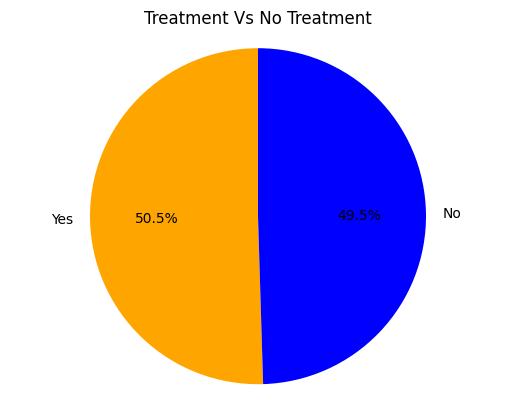

In [ ]:
# Distribution of the participants who sought treatment for mental health vs those who did not
treatment = df_clean['treatment'].value_counts()

color_map = {'No': 'blue', 'Yes': 'orange'}
colors = [color_map[label] for label in treatment.index]

plt.pie(treatment, labels=treatment.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.axis('equal')
plt.title('Treatment Vs No Treatment')
plt.show()

The distribution between participants who sought treatment and those who did not was relatively balanced, with 50.5% reporting treatment and 49.5% reporting no treatment. This balanced distribution allows for meaningful comparison between the two groups.

In [ ]:
df_plot = df_clean.groupby(['family_history', 'treatment']).size().reset_index(name='count')

fig = px.bar(df_plot,
             x='family_history',
             y='count',
             color='treatment',
             color_discrete_map={
                  "No": "blue",
                  "Yes": "orange"
             },
             barmode='group',
             title='Treatment vs Family History',
             labels={'family_history': 'Family History of Mental Health Issues',
                     'count': 'Number of Participants',
                     'treatment': 'On Treatment?'})
fig.update_layout(width=900, height=500)

fig.show()

Participants with a family history of mental health issues were notably more likely to seek treatment. Specifically, 84,540 (~73% of participants with a family history of mental health) individuals in this group sought treatment compared to only 30,992 who did not—a gap of over 53,000. Conversely, those without a family history were less likely to seek help, with roughly 50,000 more participants opting out of treatment than seeking it (113,766 vs 63,066), that is roughly 35% of participants without family history that sought treatment. This suggests a strong correlation between family history and treatment-seeking behavior.

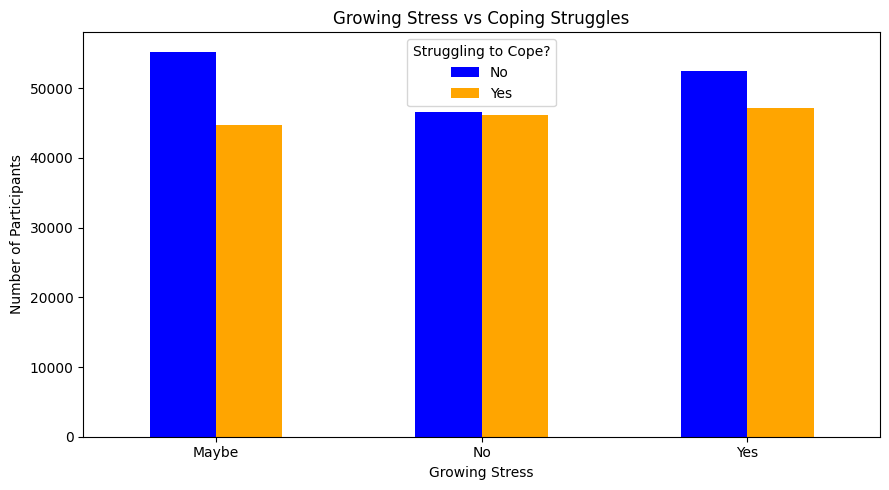

In [ ]:
gs_cs = pd.crosstab(df_clean["Growing_Stress"], df_clean["Coping_Struggles"])

gs_cs.plot(kind='bar', color=['blue', 'orange'], figsize=(9, 5))
plt.title('Growing Stress vs Coping Struggles')
plt.xlabel('Growing Stress')
plt.ylabel('Number of Participants')
plt.xticks(rotation=0)
plt.legend(title='Struggling to Cope?')
plt.tight_layout()
plt.show()

The relationship between growing stress and coping struggles appears less distinct compared to other variables analysed. Participants across all stress categories reported both coping and struggling responses in relatively similar proportions, suggesting that additional analysis may be needed to better understand this relationship.

In [ ]:
df_plot2 = df_clean.groupby(['Occupation', 'treatment']).size().reset_index(name='count')

fig = px.bar(df_plot2,
             x='Occupation',
             y='count',
             color='treatment',
             color_discrete_map={
                  "No": "blue",
                  "Yes": "orange"
             },
             barmode='group',
             title='Treatment vs Occupation',
             labels={'occupation': 'Participants Occupation',
                     'count': 'Number of Participants',
                     'treatment': 'On Treatment?'})
fig.update_layout(width=900, height=500)

fig.show()

The distribution shows an almost identical 50/50 split across all occupation categories. This indicates that occupation is not a significant predictor of treatment-seeking behavior.

In [ ]:
print(df_clean.groupby('Occupation')['treatment'].value_counts(normalize=True))


Occupation  treatment
Business    Yes         0.51
            No          0.49
Corporate   No          0.50
            Yes         0.50
Housewife   Yes         0.50
            No          0.50
Others      Yes         0.51
            No          0.49
Student     Yes         0.51
            No          0.49
Name: proportion, dtype: float64


<h1>Key Insights</h1>

*   Male participants dominated the sample population, representing approximately 82% of respondents.
*  Most of the survey participants were from the United States, indicating a geographical imbalance in the dataset.
*   Individuals with a family history of mental health conditions were significantly more likely to seek treatment.
*   The relationship between stress and coping struggles was surprisingly weak.
*   Occupation did not appear to strongly influence treatment-seeking behavior in this dataset.





<h1>Limitations</h1>

* It is important to note that this data is subject to self-reporting bias.
* The dataset is heavily skewed toward male participants, which may reduce representativeness across genders.
* Correlations observed in the analysis do not imply causation.
* Geographic concentration of participants in the US may also affect generilizability of the study to the rest of the world. Particularly countries not following Western culture.
* Some variables contained missing or ambiguous responses.

<h1>Conclusion</h1>

This analysis explored mental health trends using survey data focused on demographic characteristics, stress, coping behaviors, and treatment-seeking patterns. The most significant finding was the pivotal role of family history, which appears to be a much stronger predictor of treatment engagement than an individual's professional or social role. Interestingly, the data suggests that the decision to seek help is independent of occupation, showing a consistent distribution across all job categories.

While demographic imbalances highlight limitations in representativeness. Overall, the project demonstrates the use of data cleaning, exploratory analysis, and visualization techniques to derive meaningful public health insights from survey-based data.